In [ ]:
# Load Dataset from Google Drive


# STEP 1: Install gdown
!pip install --quiet gdown

# STEP 2: Download the CSV file from Google Drive
import gdown

# Your shared file ID
file_id = '1JJHzlWGm2YfzoQs3uTBFRR1Y68U1_viW'
output_file = 'phishing_dataset.csv'

# Download using gdown
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, quiet=False)

# STEP 3: Load into DataFrame
import pandas as pd

df = pd.read_csv('phishing_dataset.csv')
df.head()


Downloading...
From: https://drive.google.com/uc?id=1JJHzlWGm2YfzoQs3uTBFRR1Y68U1_viW
To: /content/phishing_dataset.csv
100%|██████████| 203k/203k [00:00<00:00, 61.7MB/s]


,Email Text,Email Type
0,"Dear Jordan, your subscription has been succes...",Safe Email
1,"Dear Casey, thank you for your purchase. Your ...",Safe Email
2,Congratulations! You've won a $3000 gift card....,Phishing Email
3,You have a new secure message from your bank. ...,Phishing Email
4,Your package delivery is pending. Please provi...,Phishing Email


In [ ]:
# Data Preprocessing


# STEP 4: PREPROCESSING FUNCTION
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re
from sklearn.feature_extraction.text import CountVectorizer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Clean + Preprocess function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Tokenize and remove stopwords + stemming
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to 'Email Text' column
df['clean_text'] = df['Email Text'].apply(preprocess_text)

#Encode labels ('Safe Email' = 0 , 'Phishing Email' =1)
df['label'] = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

# STEP 6:  Split features and labels
X = df['clean_text']
y = df['label']

# STEP 7: train-test split (75% train and 25% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# STEP 8: VECTORIZATION using CountVectorizer
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# STEP 9: Model Training and Evaluation


# Create a function for training and evaluating models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

#Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def train_and_evaluate(model, model_name):
    print(f"\n=======================")
    print(f"Model: {model_name}")
    print(f"=======================")

    # Train model
    model.fit(X_train_vec, y_train)
    # Predict
    y_pred = model.predict(X_test_vec)

    # Evaluate performance
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print metrics
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))

    # Confusion matrix and classification report
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Logistic Regression
lr_model = LogisticRegression()
train_and_evaluate(lr_model, "Logistic Regression")

# Naive Bayes
nb_model = MultinomialNB()
train_and_evaluate(nb_model, "Naive Bayes")

# Decision Tree
dt_model = DecisionTreeClassifier()
train_and_evaluate(dt_model, "Decision Tree")

# SVM
svm_model = SVC()
train_and_evaluate(svm_model, "Support Vector Machine")



Model: Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix:
 [[256   0]
 [  0 244]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       256
           1       1.00      1.00      1.00       244

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500


Model: Naive Bayes
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix:
 [[256   0]
 [  0 244]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       256
           1       1.00      1.00      1.00       244

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500


Model: Decision Tree
Accuracy: 1.0
Precision: 1.0
R

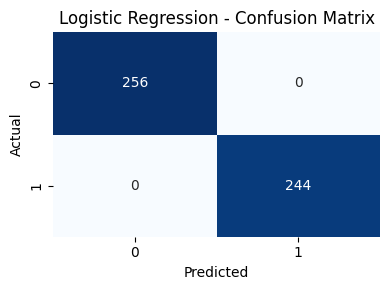

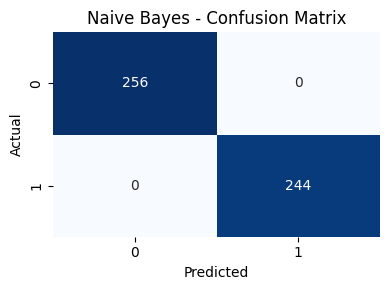

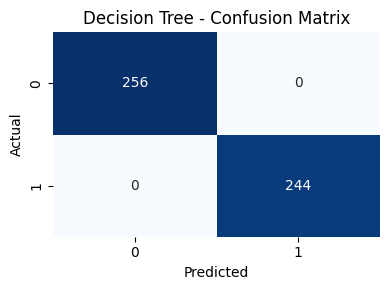

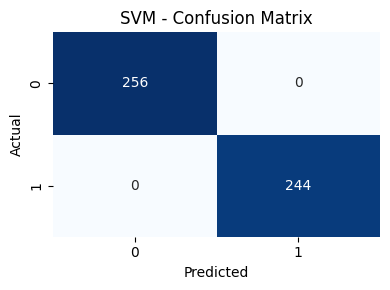

In [ ]:
# Visualization – Confusion Matrices


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Helper function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

# Generate predictions
lr_model = LogisticRegression().fit(X_train_vec, y_train)
nb_model = MultinomialNB().fit(X_train_vec, y_train)
dt_model = DecisionTreeClassifier().fit(X_train_vec, y_train)
svm_model = SVC().fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)
nb_pred = nb_model.predict(X_test_vec)
dt_pred = dt_model.predict(X_test_vec)
svm_pred = svm_model.predict(X_test_vec)

# Plot for each model
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression")
plot_confusion_matrix(y_test, nb_pred, "Naive Bayes")
plot_confusion_matrix(y_test, dt_pred, "Decision Tree")
plot_confusion_matrix(y_test, svm_pred, "SVM")


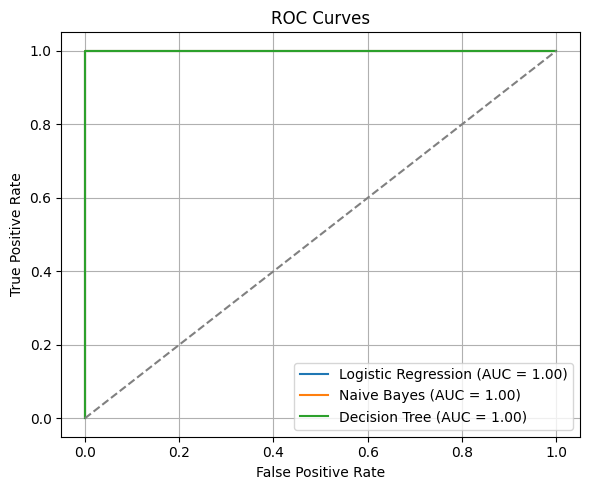

In [ ]:

# Visualization – ROC Curves (Clean)


from sklearn.metrics import roc_curve, auc

# Retrain only once with probability=True where needed
lr_model = LogisticRegression().fit(X_train_vec, y_train)
nb_model = MultinomialNB().fit(X_train_vec, y_train)
dt_model = DecisionTreeClassifier().fit(X_train_vec, y_train)

# Plot ROC curves
plt.figure(figsize=(6, 5))

def plot_roc_curve(model, X_test, y_test, model_name):
    # get predicted probabilities
    probs = model.predict_proba(X_test)[:, 1]
    # get False Positive Rate, True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    # Plot each model's ROC
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot one time per model only
plot_roc_curve(lr_model, X_test_vec, y_test, "Logistic Regression")
plot_roc_curve(nb_model, X_test_vec, y_test, "Naive Bayes")
plot_roc_curve(dt_model, X_test_vec, y_test, "Decision Tree")

# Add reference diagonal
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df['label'] = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})


In [ ]:
# Recalculate results
results = []

models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'Decision Tree': dt_model,
    'SVM': svm_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])

# Create the summary table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
results_df.set_index('Model', inplace=True)
display(results_df)


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,1.0,1.0,1.0,1.0
Naive Bayes,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0


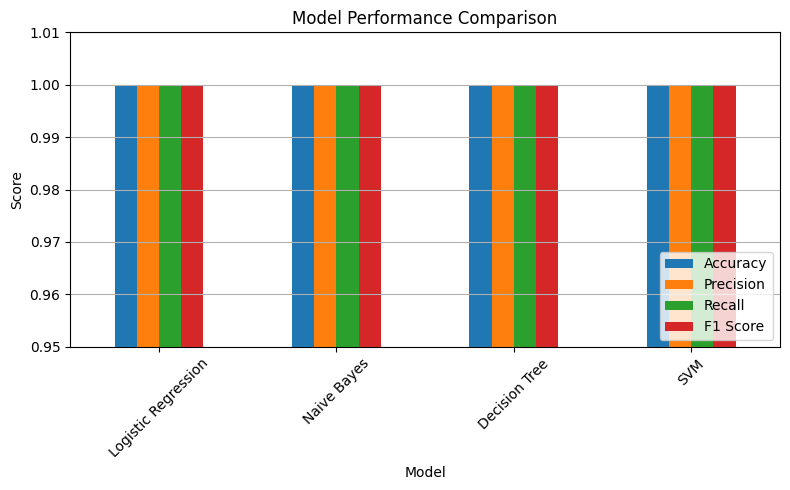

In [ ]:
#Bar Chart of Model Performance
results_df.plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.95, 1.01)
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Reapply preprocessing if 'clean_text' is missing
df['clean_text'] = df['Email Text'].apply(preprocess_text)



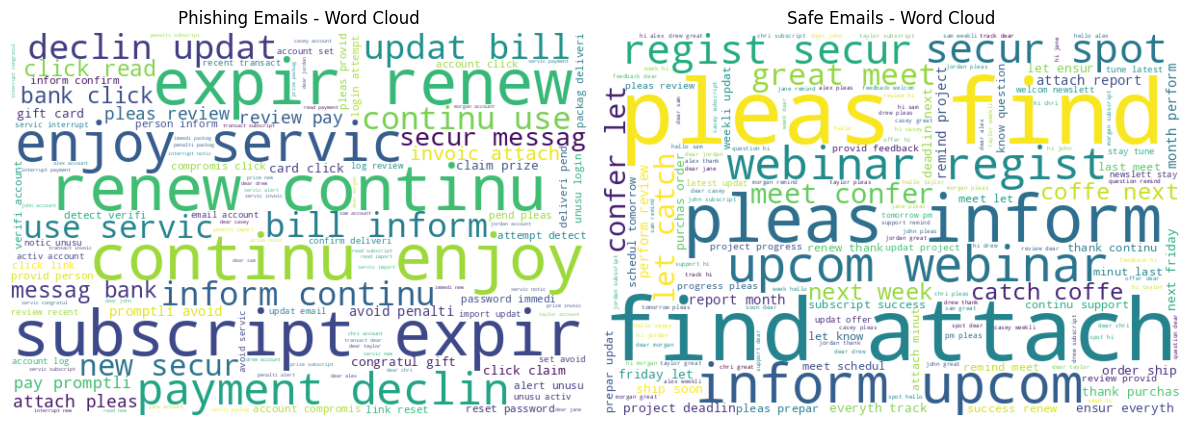

In [42]:
# Word Clouds


from wordcloud import WordCloud

# Generate for phishing emails
phishing_words = ' '.join(df[df['label'] == 1]['clean_text'])
safe_words = ' '.join(df[df['label'] == 0]['clean_text'])

plt.figure(figsize=(12, 5))

# Phishing Word Cloud
plt.subplot(1, 2, 1)
plt.title('Phishing Emails - Word Cloud')
wordcloud1 = WordCloud(width=600, height=400, background_color='white').generate(phishing_words)
plt.imshow(wordcloud1, interpolation='bilinear')
plt.axis('off')

# Safe Word Cloud
plt.subplot(1, 2, 2)
plt.title('Safe Emails - Word Cloud')
wordcloud2 = WordCloud(width=600, height=400, background_color='white').generate(safe_words)
plt.imshow(wordcloud2, interpolation='bilinear')
plt.axis('off')

plt.tight_layout()
plt.show()
